# **EDA**

`reddit_clean` and `rappler_clean` will be used.

---
**Basic dataset overview**

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from wordcloud import WordCloud
from wordcloud import STOPWORDS

reddit_clean = pd.read_csv(r"../data/Reddit/reddit_clean.csv")
rappler_clean = pd.read_csv(r"../data/News/rappler_clean.csv")

reddit_clean.info()
rappler_clean.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12730 entries, 0 to 12729
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   post_title   12730 non-null  object
 1   post_url     12730 non-null  object
 2   comment      12503 non-null  object
 3   post_body    227 non-null    object
 4   created_utc  12730 non-null  object
 5   post_full    12730 non-null  object
dtypes: object(6)
memory usage: 596.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   title           121 non-null    object
 1   link            121 non-null    object
 2   date_published  121 non-null    object
 3   text            121 non-null    object
 4   cleaned_text    121 non-null    object
dtypes: object(5)
memory usage: 4.9+ KB


In [35]:
# # Stopwrods

# import nltk
# from nltk.corpus import stopwords

# nltk.download("stopwords")
# english_stop = stopwords.words("english")

# filipino_stopwords = [
#     "sa","ang","ng","mga","si","ni","kay","kina",
#     "ito","iyan","iyon","doon","diyan","dito",
#     "ko","mo","nya","niya","natin","namin","nyo","ninyo",
#     "sila","kami","tayo","kayo",
#     "ay","may","wala","meron","naman","rin","din",
#     "pa","ba","po","ho","eh","yung","yup","nope",
#     "kung","kapag","pero","kasi","para","habang","bago",
#     "nga","lang","daw","raw","yata","pala","talaga",
#     "siguro","naka","ni","siya",
    
#     # noise words
#     "haha","hahaha","hehe","lol","omg","hmmmm","hmmmmmm",
#     "tsk","hay","amp","grabe",
    
#     # more noise as the code is ran
#     "lalala", "brgy", "sen", "ph", "phl", "gov",
#     "committee", "chairmanships", "said", "s",
# ]

# combined_stopwords = list(set(english_stop + filipino_stopwords))



---
**Word Cloud based on Word Frequency**

In [36]:
def generate_wordcloud(text_series, title, extra_stopwords=None):
    all_text = ' '.join(text_series)
    
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_text)
    
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=16)
    plt.show()

# --- Function to compute text stats ---
def add_text_stats(df, column):
    df['text_length'] = df[column].apply(len)
    df['word_count'] = df[column].apply(lambda x: len(x.split()))
    return df

# --- Function to plot Seaborn visualizations ---
def plot_text_stats(df, dataset_name):
    plt.figure(figsize=(12,5))
    
    # Text length histogram
    plt.subplot(1,2,1)
    sns.histplot(df['text_length'], bins=30, kde=True, color='skyblue')
    plt.title(f'{dataset_name} Text Length Distribution')
    plt.xlabel('Characters')
    
    # Word count histogram
    plt.subplot(1,2,2)
    sns.histplot(df['word_count'], bins=30, kde=True, color='salmon')
    plt.title(f'{dataset_name} Word Count Distribution')
    plt.xlabel('Words')
    
    plt.tight_layout()
    plt.show()
    

Reddit Text Stats Summary:
        text_length   word_count
count  12730.000000  12730.00000
mean      99.799921     15.90055
std      126.707288     20.28687
min        4.000000      1.00000
25%       55.000000      9.00000
50%       72.000000     12.00000
75%      114.000000     20.00000
max     6082.000000   1006.00000


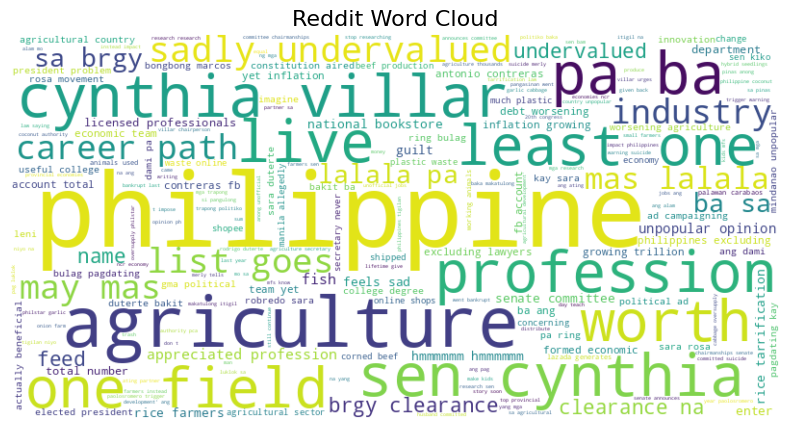

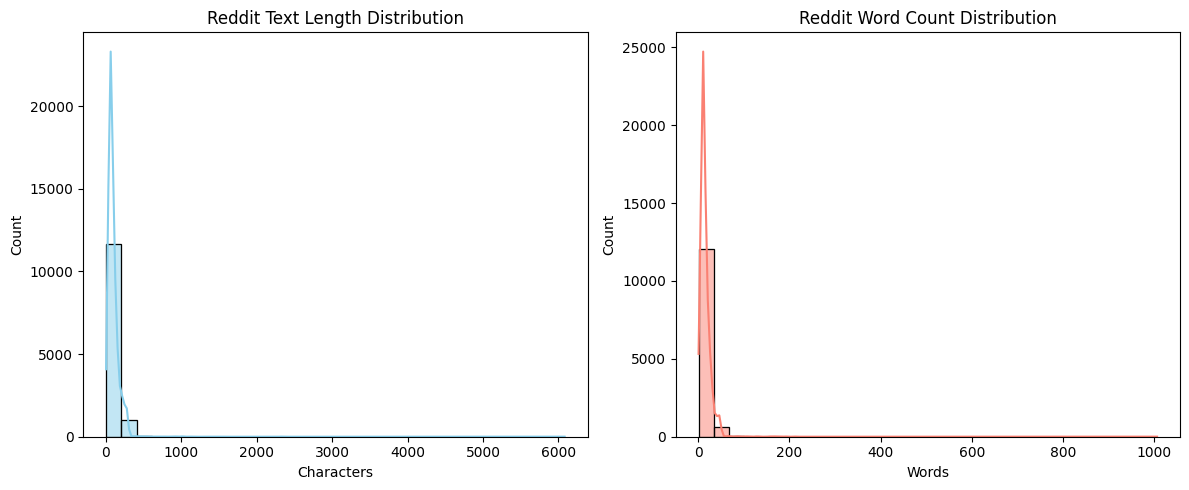

In [37]:
# reddit_clean = ["post_full"]

reddit_clean = add_text_stats(reddit_clean, "post_full")
print("Reddit Text Stats Summary:")
print(reddit_clean[['text_length', 'word_count']].describe())
generate_wordcloud(reddit_clean['post_full'], "Reddit Word Cloud")
plot_text_stats(reddit_clean, "Reddit")

Rappler Text Stats Summary:
        text_length   word_count
count    121.000000   121.000000
mean    3791.082645   595.752066
std     2110.447329   334.902630
min      437.000000    67.000000
25%     2191.000000   341.000000
50%     3295.000000   509.000000
75%     4873.000000   738.000000
max    10015.000000  1647.000000


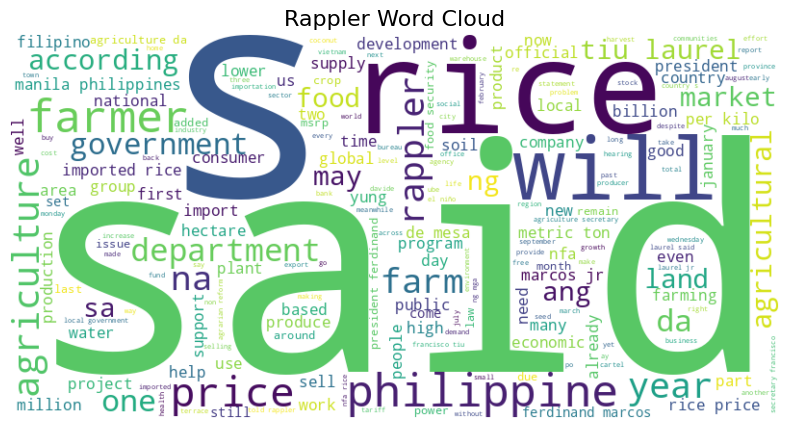

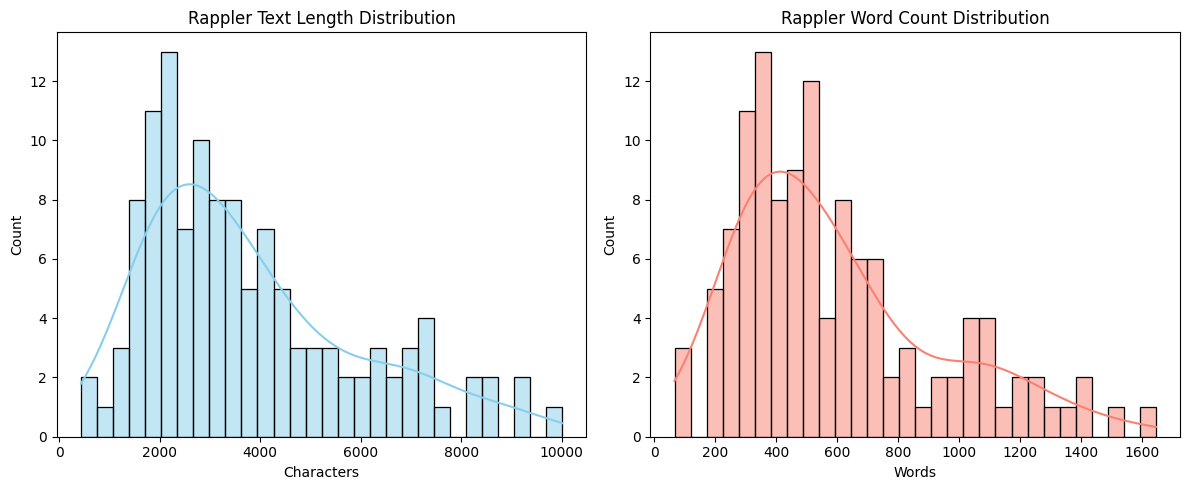

In [38]:
rappler_clean = add_text_stats(rappler_clean, "cleaned_text")
print("Rappler Text Stats Summary:")
print(rappler_clean[['text_length', 'word_count']].describe())
generate_wordcloud(rappler_clean['cleaned_text'], "Rappler Word Cloud")
plot_text_stats(rappler_clean, "Rappler")


---
**Getting top words**

In [39]:
from collections import Counter
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

def get_top_words(text_series, n=20, extra_stopwords=None):
    """
    Returns top n frequent words (excluding stopwords)
    """
    all_text = ' '.join(text_series).lower().split()
    stop_words_set = set(stopwords.words('english'))
    if extra_stopwords:
        stop_words_set.update(extra_stopwords)
    
    filtered_words = [w for w in all_text if w.isalpha()]
    word_freq = Counter(filtered_words)
    return word_freq.most_common(n)


[nltk_data] Downloading package stopwords to /Users/uwie/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [40]:
reddit_top_words = get_top_words(reddit_clean['post_full'], n=20)
print("Reddit Top 20 Words:")
print(reddit_top_words)

rappler_top_words = get_top_words(rappler_clean['cleaned_text'], n=20)
print("Rappler Top 20 Words:")
print(rappler_top_words)


Reddit Top 20 Words:
[('the', 10359), ('to', 4956), ('in', 4751), ('of', 3324), ('a', 2904), ('is', 2872), ('agriculture', 2568), ('and', 2437), ('for', 2360), ('sa', 2002), ('you', 1878), ('na', 1554), ('on', 1388), ('that', 1304), ('ang', 1302), ('ng', 1264), ('rice', 1118), ('agricultural', 1112), ('at', 1089), ('or', 1071)]
Rappler Top 20 Words:
[('the', 4329), ('of', 2148), ('to', 1894), ('and', 1772), ('in', 1547), ('a', 1165), ('that', 700), ('is', 663), ('for', 626), ('on', 547), ('rice', 478), ('with', 425), ('from', 418), ('as', 416), ('said', 405), ('at', 347), ('are', 338), ('it', 330), ('by', 315), ('was', 305)]


In [44]:
# Define Filipino stopwords
filipino_stopwords = {'na', 'sa', 'ang', 'mga', 'pa', 'ba', 'ng', 'ay', 'si', 'ni', 'kay', 'may', 'also', 'mas'}

# Get top words excluding English + Filipino stopwords
reddit_top_words = get_top_words(
    reddit_clean['post_full'], 
    n=20, 
    # extra_stopwords=filipino_stopwords
)
print("Reddit Top 20 Words:")
print(reddit_top_words)

rappler_top_words = get_top_words(
    rappler_clean['cleaned_text'], 
    n=20, 
    extra_stopwords=filipino_stopwords
)
print("Rappler Top 20 Words:")
print(rappler_top_words)



Reddit Top 20 Words:
[('the', 10359), ('to', 4956), ('in', 4751), ('of', 3324), ('a', 2904), ('is', 2872), ('agriculture', 2568), ('and', 2437), ('for', 2360), ('sa', 2002), ('you', 1878), ('na', 1554), ('on', 1388), ('that', 1304), ('ang', 1302), ('ng', 1264), ('rice', 1118), ('agricultural', 1112), ('at', 1089), ('or', 1071)]
Rappler Top 20 Words:
[('the', 4329), ('of', 2148), ('to', 1894), ('and', 1772), ('in', 1547), ('a', 1165), ('that', 700), ('is', 663), ('for', 626), ('on', 547), ('rice', 478), ('with', 425), ('from', 418), ('as', 416), ('said', 405), ('at', 347), ('are', 338), ('it', 330), ('by', 315), ('was', 305)]


---
Post frequency over time

In [42]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

def plot_posts_over_time(df, date_column, dataset_name):
    """
    Plots number of posts/articles per day using Seaborn
    """
    # Ensure datetime
    df[date_column] = pd.to_datetime(df[date_column], errors='coerce')
    
    # Count posts per day
    ts = df.groupby(df[date_column].dt.date).size().reset_index(name='count')
    ts.rename(columns={date_column: 'date'}, inplace=True)
    
    # Plot with Seaborn
    plt.figure(figsize=(14,5))
    sns.lineplot(data=ts, x='date', y='count', marker='o')
    plt.title(f'{dataset_name} Posts Over Time', fontsize=16)
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Number of Posts', fontsize=12)
    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


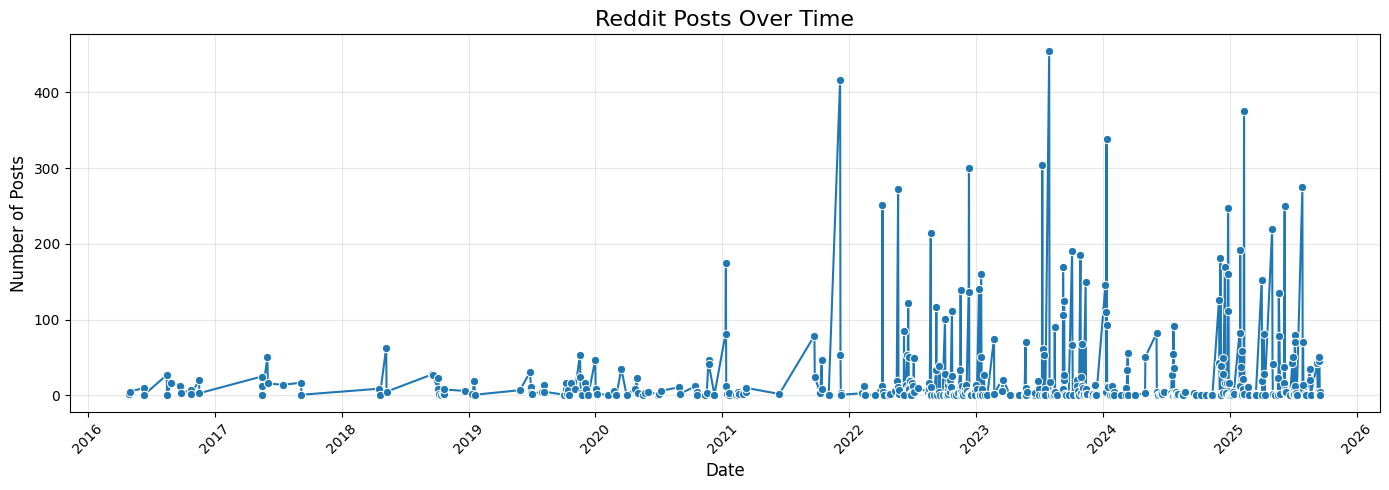

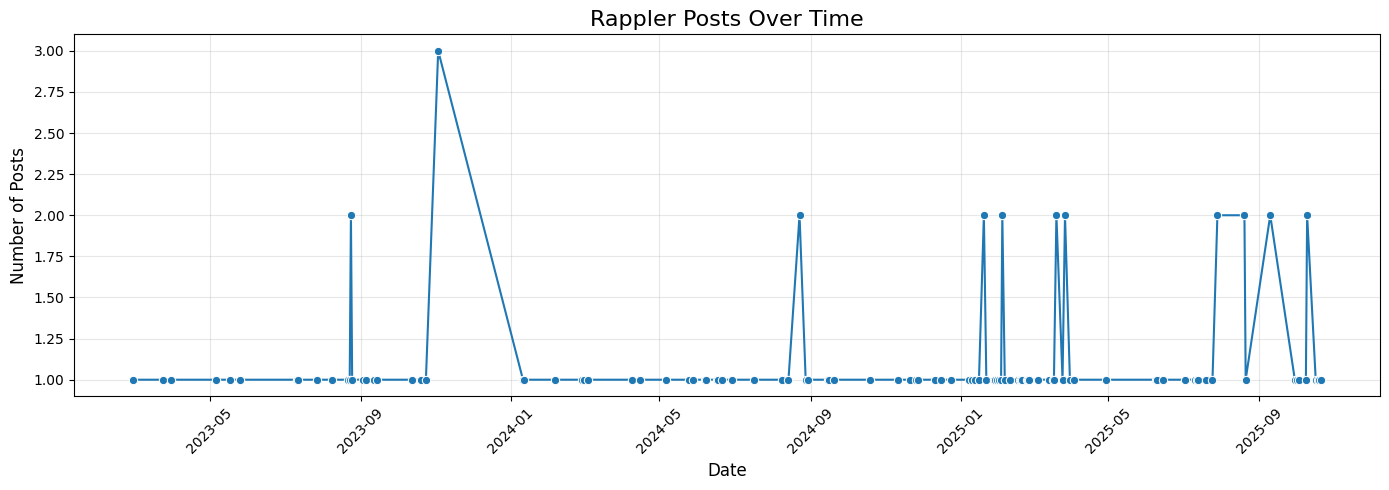

In [43]:
plot_posts_over_time(reddit_clean, 'created_utc', 'Reddit')
plot_posts_over_time(rappler_clean, 'date_published', 'Rappler')


---
**Summary of EDA**

The EDA included:
1. Inspecting dataset structure using data.info().
2. Generating a basic (but still noisy) word cloud from raw word frequencies.
3. Identifying the top most frequent words.
4. Plotting post frequency over time to observe activity trends.